# Beyond Spotify: English Wikipedia attention

## tl;dr

English Wikipedia pageviews are available for
**924/1000 bands
(92.4%)** over July 2025–June 2026. Their rank
correlation with Spotify followers is **0.77**:
the measures overlap, but are not interchangeable. Ant & Dec has
the largest positive residual from the descriptive log–log fit. Wikipedia
pageviews measure attention and information seeking, not listening or local
audience, so this is triangulation rather than validation of one "true" impact
metric.

## Context and methods

The beyond-Spotify branch joins the popularity-first top 1,000 to their Wikidata
English-Wikipedia sitelinks and twelve monthly Wikimedia pageview aggregates.
It compares annual user pageviews with Spotify followers using ranks and a
descriptive log–log fit. Positive residuals identify bands receiving more
Wikipedia attention than their follower count predicts within this sample.

### Assumptions

English Wikipedia omits attention in other languages and can respond strongly
to news, deaths, anniversaries or controversy. Pageviews include repeat visits
but exclude automated agents. The Spotify follower count is a point-in-time
stock, whereas pageviews cover a year.

Source documentation: [Wikimedia page-view API](https://doc.wikimedia.org/generated-data-platform/aqs/analytics-api/reference/page-views.html).

## Data

Aggregate the frozen monthly pageview responses and join by Wikidata ID.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src/python_uk_bands").exists():
    ROOT = next(
        parent for parent in Path.cwd().resolve().parents
        if (parent / "src/python_uk_bands").exists()
    )
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = ROOT / "artifacts/experiments/beyond_spotify/20250701_20260630"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
from python_uk_bands.review_extension_experiments import (
    build_beyond_spotify,
    plot_attention_residuals,
    plot_spotify_vs_pageviews,
)

PAGEVIEWS_PATH = ROOT / (
    "data/raw/wikimedia/"
    "top1000_enwiki_pageviews_20250701_20260630_20260725.json"
)
band_audit, city_summary, summary = build_beyond_spotify(
    ROOT, pageviews_path=PAGEVIEWS_PATH
)

assert len(band_audit) == 1000
assert band_audit["popularity_rank"].is_unique
assert band_audit["pageviews_total"].ge(0).all()
assert summary["comparable_bands"] <= summary["bands_with_pageviews"]
assert city_summary[["follower_share", "pageview_share"]].sum().round(10).eq(1).all()

band_audit.to_csv(ARTIFACT_DIR / "band_pageview_audit.csv", index=False)
city_summary.to_csv(ARTIFACT_DIR / "city_pageview_summary.csv", index=False)
(ARTIFACT_DIR / "coverage_summary.json").write_text(
    json.dumps(summary, indent=2, sort_keys=True) + "\n"
)

display(Markdown(
    f"**{summary['bands_with_pageviews']}/{summary['selected_bands']} pageview coverage · "
    f"{summary['comparable_bands']} comparable positive observations · "
    f"rank correlation {summary['rank_correlation_followers_vs_pageviews']:.2f}**"
))

**924/1000 pageview coverage · 924 comparable positive observations · rank correlation 0.77**

## Results

### 1. How closely do follower stocks and Wikipedia attention align?

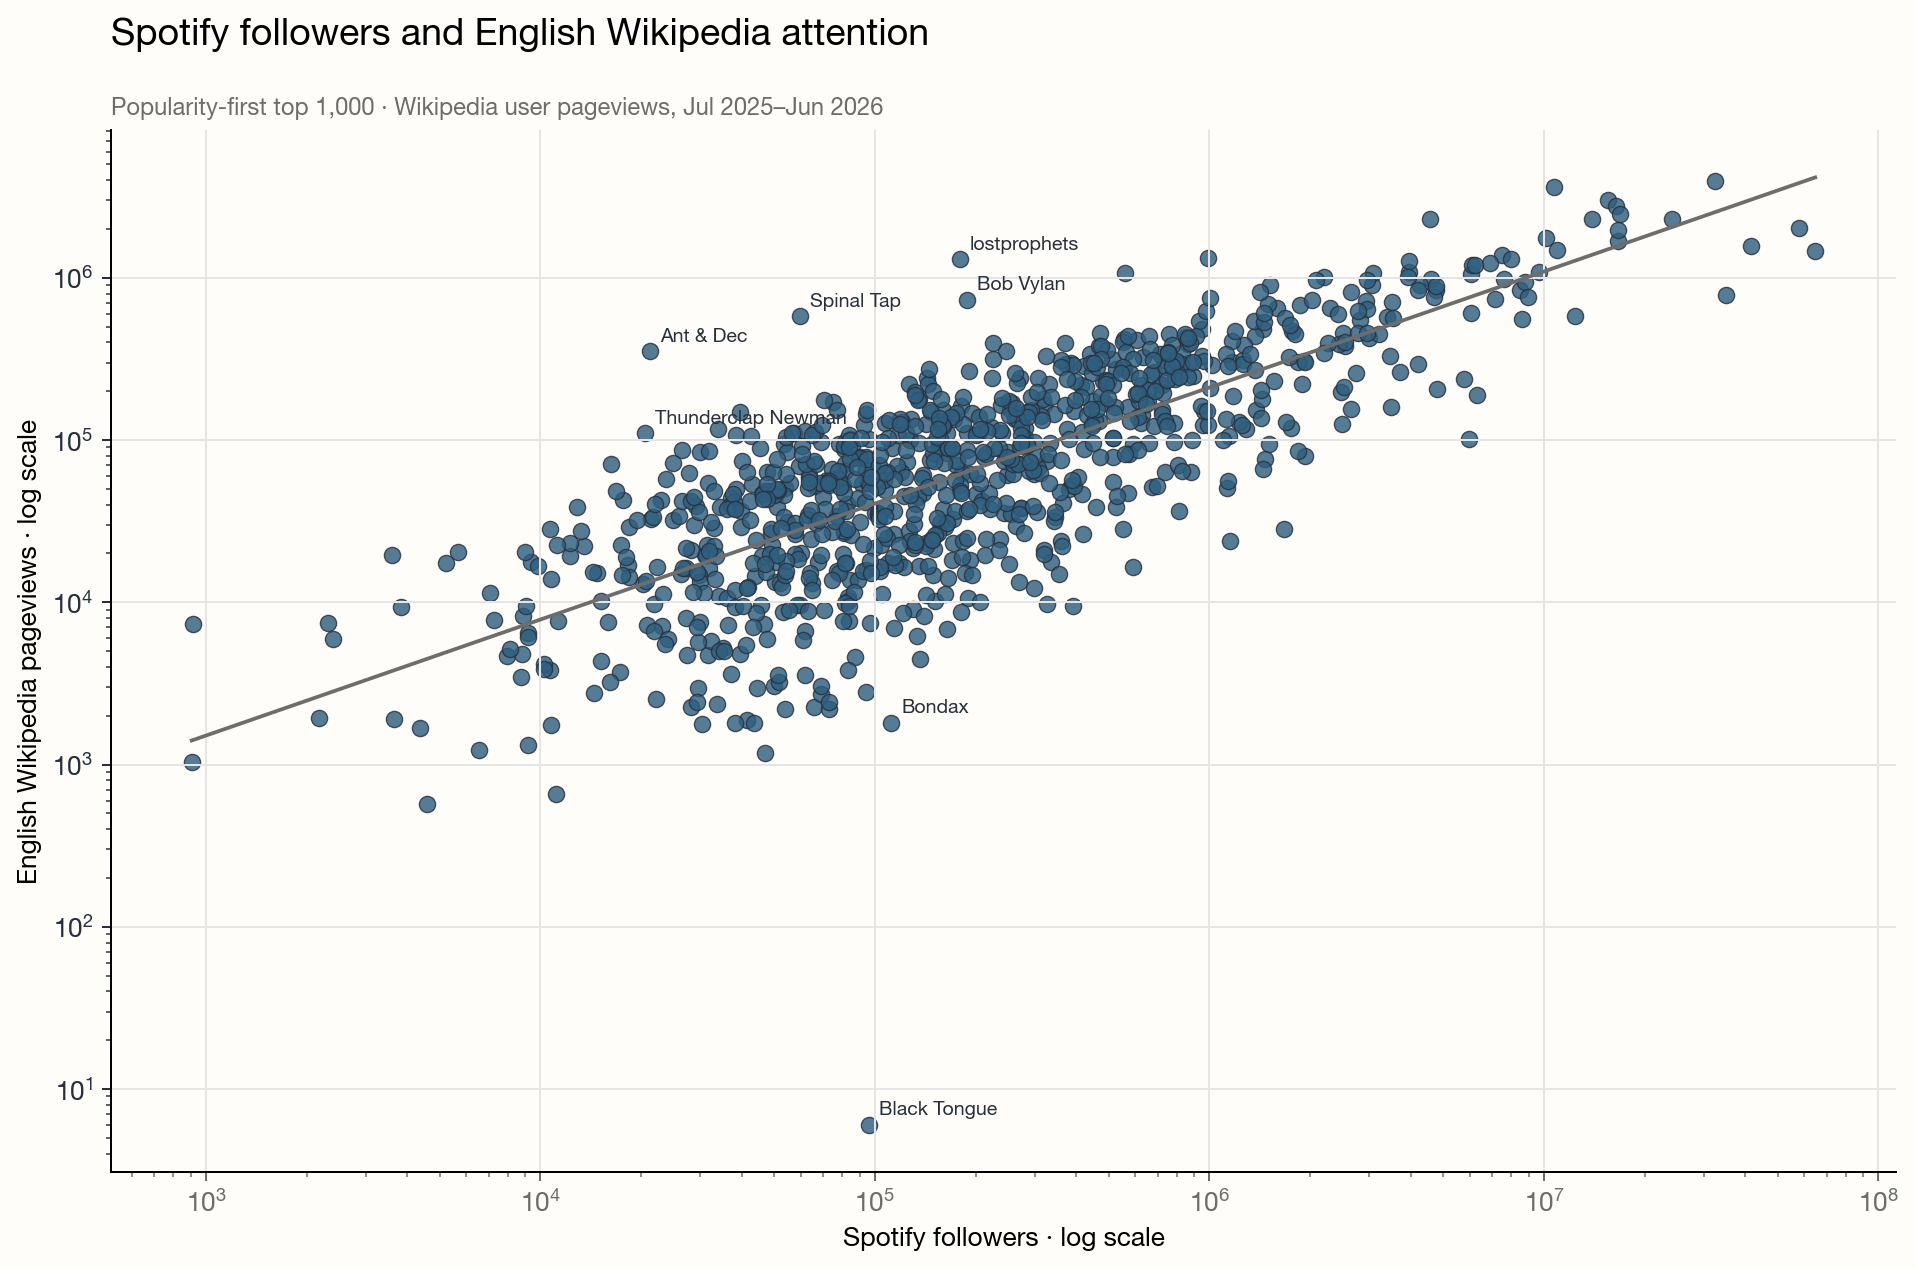

Measure,Value
Coverage,924/1000
Rank correlation,0.77
Log–log slope,0.72


In [3]:
scatter_path = plot_spotify_vs_pageviews(
    band_audit,
    output_path=ARTIFACT_DIR / "chart_01_followers_vs_pageviews.png",
)
display(Image(filename=str(scatter_path)))

display(pd.DataFrame({
    "Measure": ["Coverage", "Rank correlation", "Log–log slope"],
    "Value": [
        f"{summary['bands_with_pageviews']}/{summary['selected_bands']}",
        f"{summary['rank_correlation_followers_vs_pageviews']:.2f}",
        f"{summary['log_model_slope']:.2f}",
    ],
}).style.hide(axis="index"))

### 2. Which bands receive unusually high Wikipedia attention?

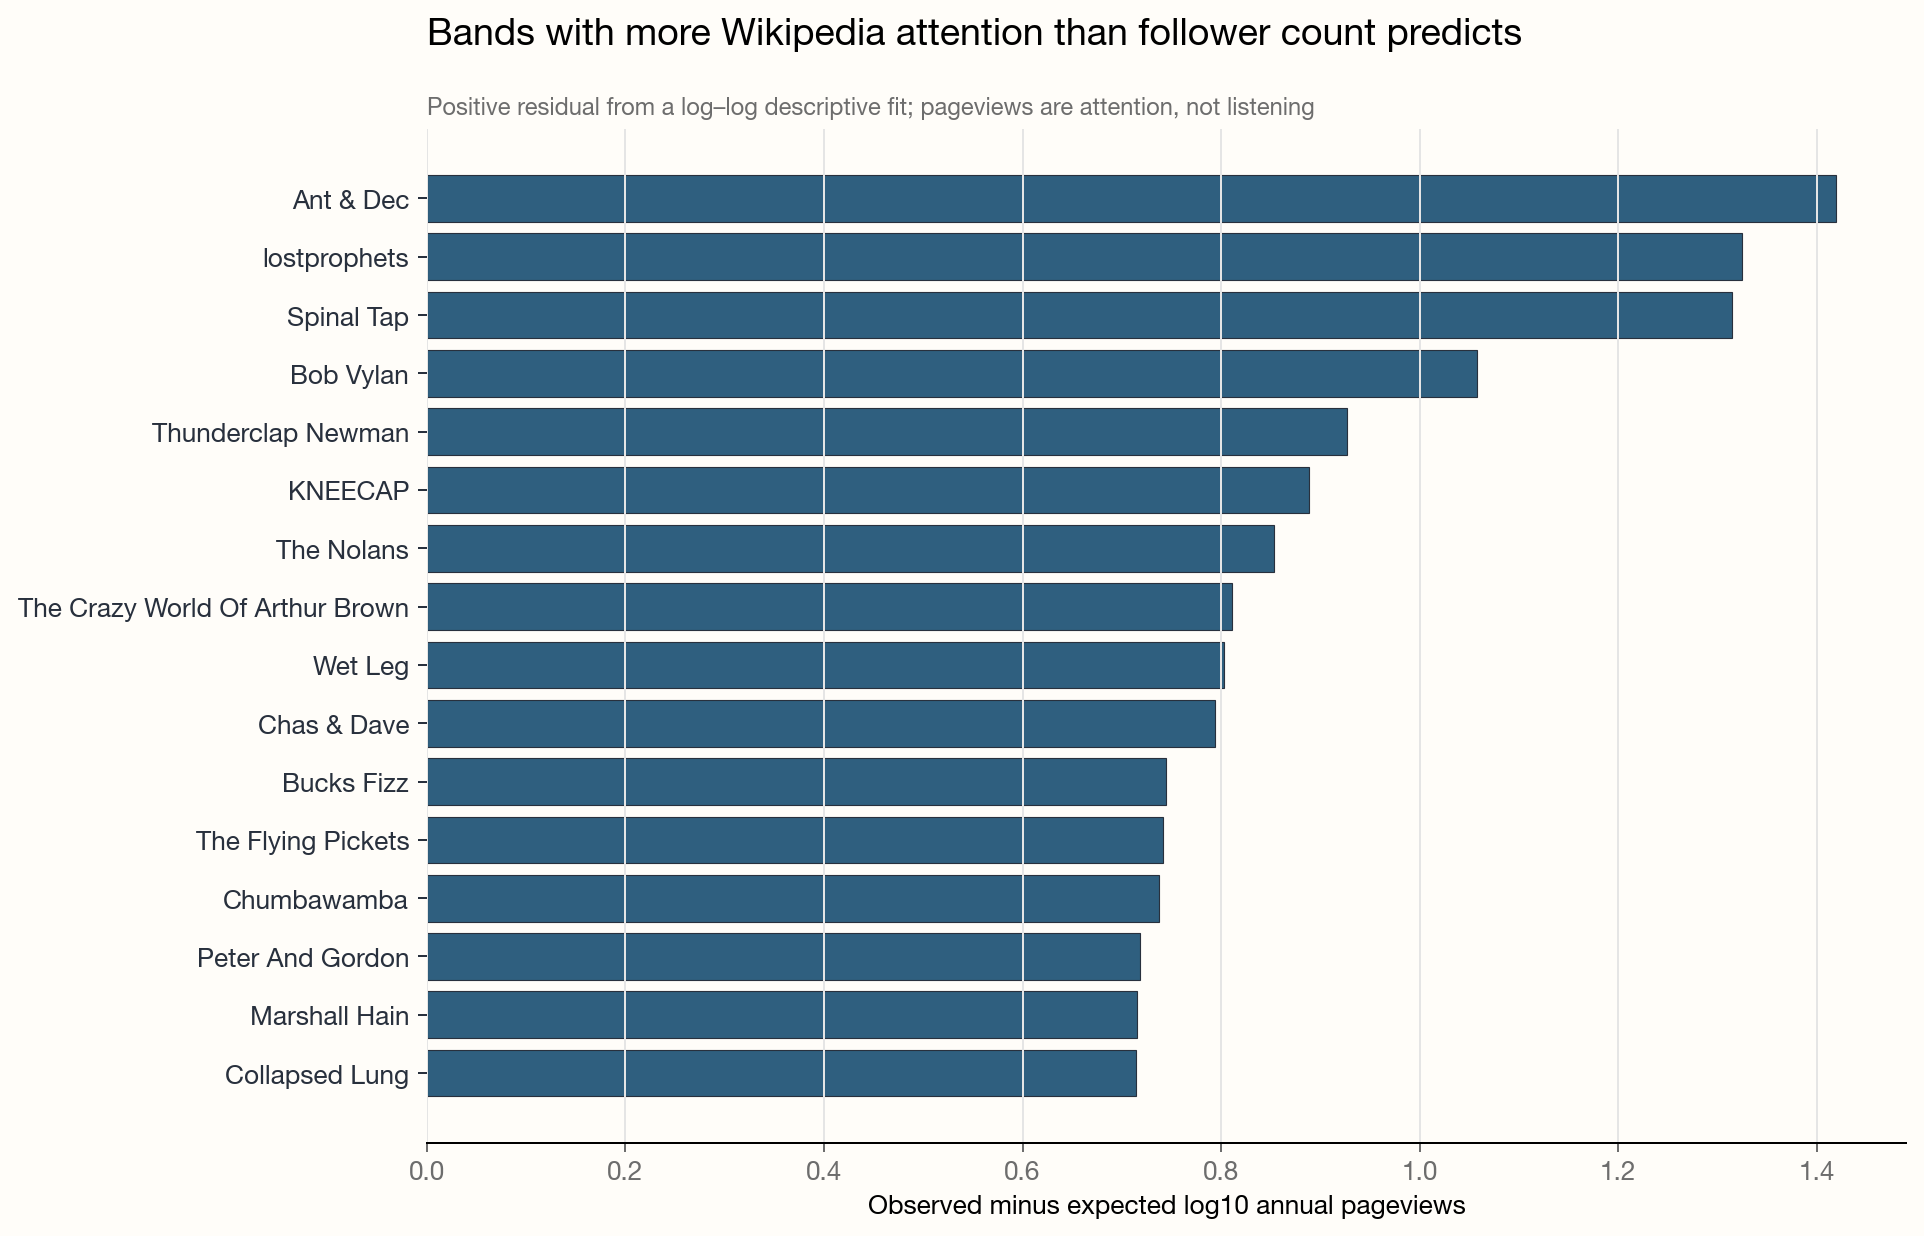

spotify_name,followers,enwiki_title,pageviews_total,follower_rank,pageview_rank,attention_residual_log10
Ant & Dec,"21,248",Ant & Dec,"352,039",861.000000,112.000000,+1.42
lostprophets,"179,652",Lostprophets,"1,303,745",434.000000,18.000000,+1.32
Spinal Tap,"59,910",Spinal Tap (band),"581,165",696.000000,65.000000,+1.31
Bob Vylan,"188,980",Bob Vylan,"731,108",421.000000,51.000000,+1.06
Thunderclap Newman,"20,516",Thunderclap Newman,"110,449",864.000000,342.000000,+0.93
KNEECAP,"558,490",Kneecap (band),"1,073,703",223.000000,26.000000,+0.89
The Nolans,"39,473",The Nolans,"149,128",779.000000,267.000000,+0.85
The Crazy World Of Arthur Brown,"16,217",The Crazy World of Arthur Brown,"71,526",876.000000,448.000000,+0.81
Wet Leg,"989,381",Wet Leg,"1,329,952",135.000000,17.000000,+0.80
Chas & Dave,"34,026",Chas & Dave,"116,945",800.000000,331.000000,+0.79


In [4]:
residual_path = plot_attention_residuals(
    band_audit,
    output_path=ARTIFACT_DIR / "chart_02_attention_residuals.png",
)
display(Image(filename=str(residual_path)))

display(band_audit.dropna(subset=["attention_residual_log10"]).sort_values(
    "attention_residual_log10", ascending=False
).head(25)[[
    "spotify_name", "followers", "enwiki_title", "pageviews_total",
    "follower_rank", "pageview_rank", "attention_residual_log10",
]].style.hide(axis="index").format({
    "followers": "{:,.0f}",
    "pageviews_total": "{:,.0f}",
    "attention_residual_log10": "{:+.2f}",
}))

## Takeaways

- Spotify followers and English Wikipedia attention are strongly but
  imperfectly aligned.
- Residuals reveal bands whose cultural or news attention is not summarized by
  follower scale alone.
- Wikipedia is a useful independent attention measure, not a listening metric.
- A broader comparison could add chart history, certifications, radio,
  touring, YouTube, Last.fm and set-list activity under separate definitions.